Grafico 2 salvo com sucesso.


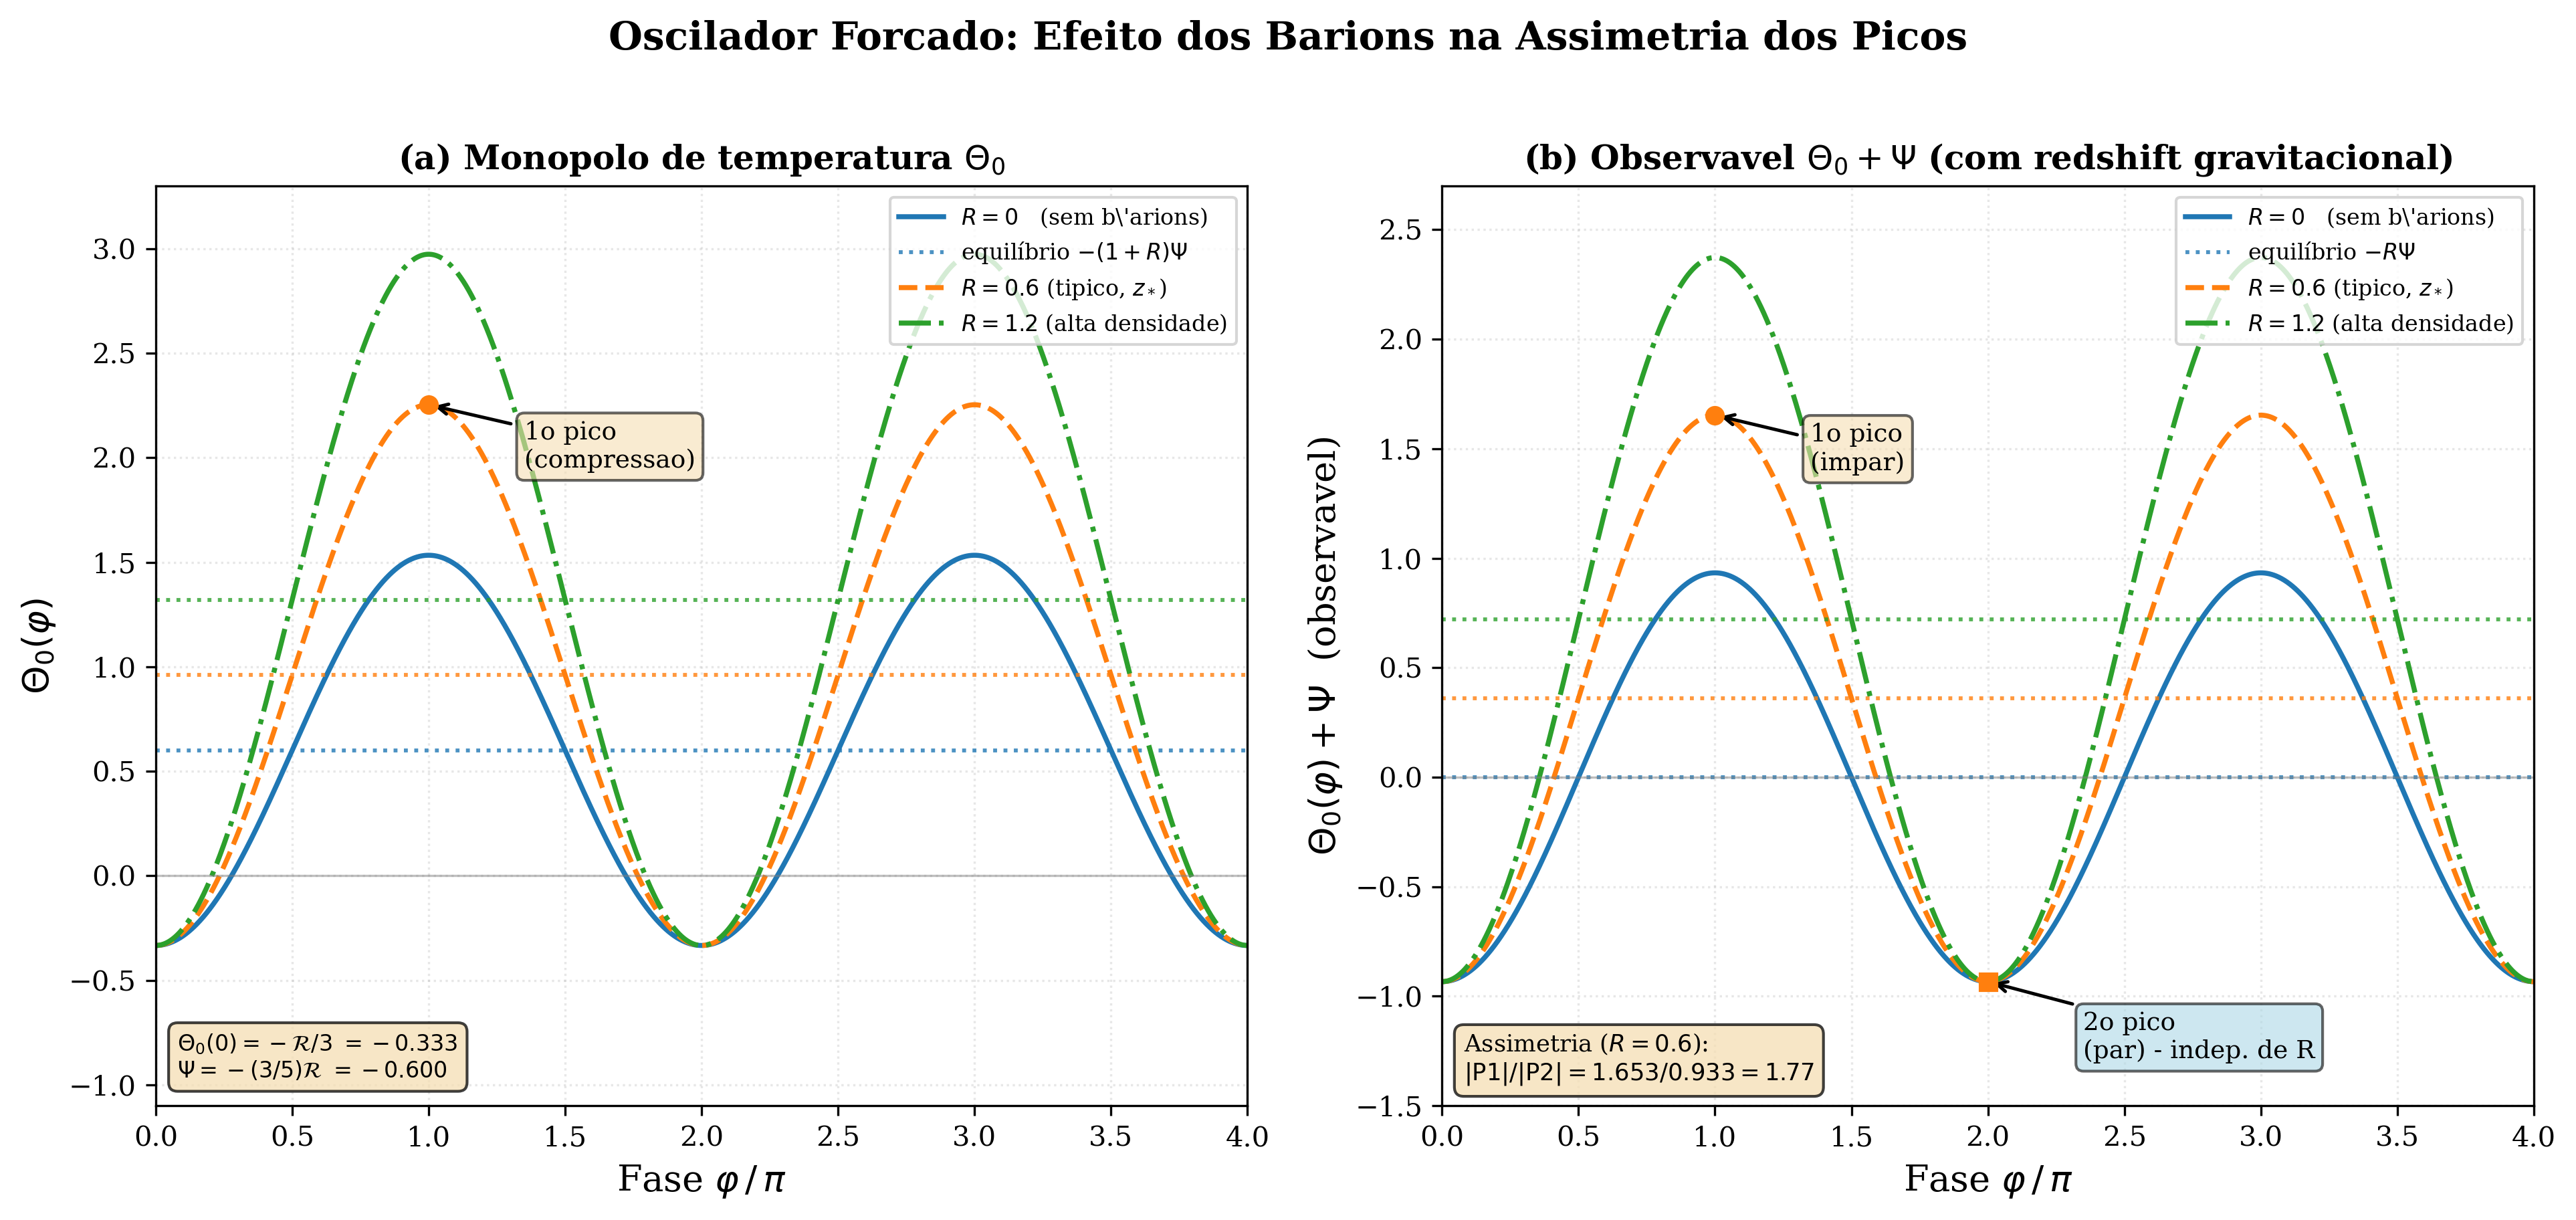


VERIFICACAO QUANTITATIVA DOS PICOS (R = 0.6)
Pico        Theta_0 Theta_0 + Psi  Tipo
1o (impar)   2.2533   1.6533  compressao
2o (par)    -0.3333  -0.9333  rarefacao
3o (impar)   2.2533   1.6533  compressao

Razao |P1|/|P2| = 1.7714

Assimetria por R:
  R = 0.0: |P1| = 0.9333, |P2| = 0.9333, razao = 1.0000
  R = 0.6: |P1| = 1.6533, |P2| = 0.9333, razao = 1.7714
  R = 1.2: |P1| = 2.3733, |P2| = 0.9333, razao = 2.5429


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# CONFIGURACOES DE ESTILO
# =============================================================================

plt.style.use('default')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})


# =============================================================================
# PARAMETROS E CONDICOES INICIAIS ADIABATICAS
# =============================================================================

R_curv = 1.0

Theta0_0 = -R_curv / 3.0
# Theta_0(0) = -R_curv / 3
# com Phi_i = (2/3) R_curv, conforme a Eq. 57

Psi = -(3.0 / 5.0) * R_curv
# Psi = -(3/5) R_curv, conforme a Eq. 58


R_values = [0.0, 0.6, 1.2]

R_labels = [
    r'$R = 0\ \ $ (sem b\'arions)',
    r'$R = 0.6$ (tipico, $z_*$)',
    r'$R = 1.2$ (alta densidade)'
]

R_colors = [
    '#1f77b4',
    '#ff7f0e',
    '#2ca02c'
]

R_styles = [
    '-',
    '--',
    '-.'
]


# =============================================================================
# FUNCOES
# =============================================================================

def theta_0(fase, R):
    """
    Retorna Theta_0(fase) conforme a Eq. 83 do TCC.

    A oscilacao ocorre em torno do equilibrio
    -(1 + R) Psi.
    """

    return (
        (Theta0_0 + (1 + R) * Psi) * np.cos(fase)
        - (1 + R) * Psi
    )


def observavel(fase, R):
    """
    Retorna a quantidade observavel Theta_0 + Psi,
    conforme a Eq. 69.

    O equilibrio correspondente e -R Psi.
    """

    return theta_0(fase, R) + Psi


# =============================================================================
# GRADE DE FASE
# =============================================================================

fase = np.linspace(0, 4 * np.pi, 2000)

# Quatro unidades de pi correspondem a dois ciclos completos.


# =============================================================================
# GRAFICO
# =============================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 6)
)

ax1, ax2 = axes


# =============================================================================
# PAINEL (a): THETA_0
# =============================================================================

first_eq_label_a = True

for R, label, color, linestyle in zip(
    R_values,
    R_labels,
    R_colors,
    R_styles
):

    ax1.plot(
        fase / np.pi,
        theta_0(fase, R),
        label=label,
        linestyle=linestyle,
        color=color,
        linewidth=1.8
    )

    # Linha de equilibrio:
    # -(1 + R) Psi

    eq_label_a = (
        r'equilíbrio $-(1+R)\Psi$'
        if first_eq_label_a
        else None
    )

    ax1.axhline(
        -(1 + R) * Psi,
        color=color,
        linestyle=':',
        linewidth=1.4,
        alpha=0.8,
        label=eq_label_a
    )

    first_eq_label_a = False


# Linha horizontal em zero
ax1.axhline(
    0,
    color='gray',
    linewidth=0.8,
    alpha=0.5
)


# Eixos
ax1.set_xlabel(
    r'Fase $\varphi\,/\,\pi$',
    fontsize=13
)

ax1.set_ylabel(
    r'$\Theta_0(\varphi)$',
    fontsize=13
)

ax1.set_xlim(0, 4)
ax1.set_ylim(-1.1, 3.3)

ax1.set_xticks(
    np.arange(0, 4.5, 0.5)
)

ax1.tick_params(
    labelsize=10
)


# Legenda
ax1.legend(
    loc='upper right',
    frameon=True,
    fontsize=8
)


ax1.grid(
    True,
    alpha=0.3,
    linestyle=':'
)


ax1.set_title(
    r'(a) Monopolo de temperatura $\Theta_0$',
    fontsize=12,
    fontweight='bold'
)


# =============================================================================
# CONDICOES INICIAIS
# =============================================================================

ax1.text(
    0.02,
    0.08,
    r'$\Theta_0(0) = -\mathcal{R}/3$'
    + f' $= {Theta0_0:.3f}$\n'
    + r'$\Psi = -(3/5)\mathcal{R}$'
    + f' $= {Psi:.3f}$',
    transform=ax1.transAxes,
    fontsize=8.0,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.75,
        pad=0.4
    )
)


# =============================================================================
# PRIMEIRO PICO NO PAINEL (a)
# =============================================================================

# Localizacao do primeiro pico: fase / pi = 1
idx_p1 = np.argmin(
    np.abs(fase / np.pi - 1.0)
)

y_p1_a = theta_0(
    fase[idx_p1],
    0.6
)


ax1.plot(
    1.0,
    y_p1_a,
    'o',
    color=R_colors[1],
    markersize=6,
    zorder=5
)


ax1.annotate(
    '1o pico\n(compressao)',
    xy=(1.0, y_p1_a),
    xytext=(1.35, y_p1_a - 0.3),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.2
    ),
    fontsize=9,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.6
    )
)


# =============================================================================
# PAINEL (b): THETA_0 + PSI
# =============================================================================

first_eq_label = True

for R, label, color, linestyle in zip(
    R_values,
    R_labels,
    R_colors,
    R_styles
):

    ax2.plot(
        fase / np.pi,
        observavel(fase, R),
        label=label,
        linestyle=linestyle,
        color=color,
        linewidth=1.8
    )

    # Linha de equilibrio:
    # -R Psi

    eq_label = (
        r'equilíbrio $-R\Psi$'
        if first_eq_label
        else None
    )

    ax2.axhline(
        -R * Psi,
        color=color,
        linestyle=':',
        linewidth=1.4,
        alpha=0.8,
        label=eq_label
    )

    first_eq_label = False


# Linha horizontal em zero
ax2.axhline(
    0,
    color='gray',
    linewidth=0.8,
    alpha=0.5
)


# Eixos
ax2.set_xlabel(
    r'Fase $\varphi\,/\,\pi$',
    fontsize=13
)

ax2.set_ylabel(
    r'$\Theta_0(\varphi) + \Psi$  (observavel)',
    fontsize=13
)

ax2.set_xlim(0, 4)
ax2.set_ylim(-1.5, 2.7)

ax2.set_xticks(
    np.arange(0, 4.5, 0.5)
)

ax2.tick_params(
    labelsize=10
)


# Legenda
ax2.legend(
    loc='upper right',
    frameon=True,
    fontsize=8
)


ax2.grid(
    True,
    alpha=0.3,
    linestyle=':'
)


ax2.set_title(
    r'(b) Observavel $\Theta_0 + \Psi$'
    r' (com redshift gravitacional)',
    fontsize=12,
    fontweight='bold'
)


# =============================================================================
# PRIMEIRO E SEGUNDO PICOS NO PAINEL (b)
# =============================================================================

# Primeiro pico: fase / pi = 1
idx_p1 = np.argmin(
    np.abs(fase / np.pi - 1.0)
)

# Segundo pico: fase / pi = 2
idx_p2 = np.argmin(
    np.abs(fase / np.pi - 2.0)
)


y_p1_b = observavel(
    fase[idx_p1],
    0.6
)

y_p2_b = observavel(
    fase[idx_p2],
    0.6
)


# Marcadores dos picos
ax2.plot(
    1.0,
    y_p1_b,
    'o',
    color=R_colors[1],
    markersize=6,
    zorder=5
)

ax2.plot(
    2.0,
    y_p2_b,
    's',
    color=R_colors[1],
    markersize=6,
    zorder=5
)


# Anotacao do primeiro pico
ax2.annotate(
    '1o pico\n(impar)',
    xy=(1.0, y_p1_b),
    xytext=(1.35, y_p1_b - 0.25),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.2
    ),
    fontsize=9,
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.6
    )
)


# Anotacao do segundo pico
ax2.annotate(
    '2o pico\n(par) - indep. de R',
    xy=(2.0, y_p2_b),
    xytext=(2.35, y_p2_b - 0.35),
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=1.2
    ),
    fontsize=9,
    bbox=dict(
        boxstyle='round',
        facecolor='lightblue',
        alpha=0.6
    )
)


# =============================================================================
# RAZAO DE ASSIMETRIA PARA R = 0.6
# =============================================================================

razao = abs(y_p1_b / y_p2_b)


ax2.text(
    0.02,
    0.08,
    r'Assimetria ($R=0.6$):' + '\n'
    rf'$|\mathrm{{P1}}|/|\mathrm{{P2}}| = '
    rf'{abs(y_p1_b):.3f}/{abs(y_p2_b):.3f} = {razao:.2f}$',
    transform=ax2.transAxes,
    fontsize=8.5,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.75,
        pad=0.4
    )
)


# =============================================================================
# TITULO E SALVAMENTO
# =============================================================================

fig.suptitle(
    'Oscilador Forcado: Efeito dos Barions na Assimetria dos Picos',
    fontsize=14,
    fontweight='bold',
    y=1.01
)


plt.tight_layout()


# Salva o grafico em PNG e PDF
plt.savefig(
    'grafico2_oscilador_forcado.png',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'grafico2_oscilador_forcado.pdf',
    dpi=300,
    bbox_inches='tight'
)


print("Grafico 2 salvo com sucesso.")


plt.show()


# =============================================================================
# VERIFICACAO QUANTITATIVA
# =============================================================================

print(f"\n{'=' * 55}")
print("VERIFICACAO QUANTITATIVA DOS PICOS (R = 0.6)")
print(f"{'=' * 55}")

print(
    f"{'Pico':<10} "
    f"{'Theta_0':>8} "
    f"{'Theta_0 + Psi':>8}  "
    f"Tipo"
)


for n, nome in [
    (1, '1o (impar)'),
    (2, '2o (par)'),
    (3, '3o (impar)')
]:

    idx = np.argmin(
        np.abs(fase / np.pi - n)
    )

    theta = theta_0(
        fase[idx],
        0.6
    )

    obs = observavel(
        fase[idx],
        0.6
    )

    tipo = (
        'compressao'
        if n % 2 == 1
        else 'rarefacao'
    )

    print(
        f"{nome:<10} "
        f"{theta:>8.4f} "
        f"{obs:>8.4f}  "
        f"{tipo}"
    )


print(
    f"\nRazao |P1|/|P2| = {razao:.4f}"
)


# =============================================================================
# ASSIMETRIA PARA DIFERENTES VALORES DE R
# =============================================================================

print("\nAssimetria por R:")


for R in R_values:

    idx_p1 = np.argmin(
        np.abs(fase / np.pi - 1.0)
    )

    idx_p2 = np.argmin(
        np.abs(fase / np.pi - 2.0)
    )

    pico_1 = observavel(
        fase[idx_p1],
        R
    )

    pico_2 = observavel(
        fase[idx_p2],
        R
    )

    razao_R = abs(pico_1 / pico_2)

    print(
        f"  R = {R:.1f}: "
        f"|P1| = {abs(pico_1):.4f}, "
        f"|P2| = {abs(pico_2):.4f}, "
        f"razao = {razao_R:.4f}"
    )
